<a href="https://colab.research.google.com/github/sandralungahi/Data-and-AI-mini-projects/blob/MLOps/MLOPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME: SANDRA LUNG'AHI

CYBER SHUJAA ID: CS-DA02-25069

WEEK 9 ASSIGNMENT: MLOPS

DESCRIPTION: Building an end to end machine learning workflow to oredict house prices using the Carlifonia housing dataset.

In [1]:
#  Step 1: Import necessary libraries

import pandas as pd
import numpy as np
import pickle
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


**1. Load and explore the dataset**

In [2]:
# Load the California Housing dataset
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# Display first few rows
X.head()

# Show summary info
print("Shape of features:", X.shape)
print("Shape of target:", y.shape)
print("\nFeature columns:\n", X.columns.tolist())

# Check for missing values
print("\nMissing values per column:\n", X.isna().sum())



Shape of features: (20640, 8)
Shape of target: (20640,)

Feature columns:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Missing values per column:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


**2. Train-test split**

In [3]:
# Split the dataset into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (16512, 8)
Test set: (4128, 8)


**3. Preprocessing: Imputation and Scaling for numerical features**

In [4]:
# Define numeric features
numeric_features = X.columns.tolist()

# Define transformation pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
    ])


**4. Combine preprocessing using ColumnTransformer**

In [5]:
# Combine all transformations into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

**5. Define the KNN model with a pipeline**

In [6]:
# Build a complete pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])


**6. Hyperparameter Tuning with GridSearchCV**

In [7]:
# Define the parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

**7. Train the Model using GridSearchCV**

In [8]:
# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator
best_model = grid_search.best_estimator_

# Display best hyperparameters and best cross-validation score
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV R² Score: 0.7313


**8. Evaluate Model on Test Set**

In [10]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Compute metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Manually compute RMSE

# Print metrics
print(f"Test R² Score: {r2:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")



Test R² Score: 0.7221
Test MSE: 0.3642
Test RMSE: 0.6034


**9. Visualize predictions vs actual values**

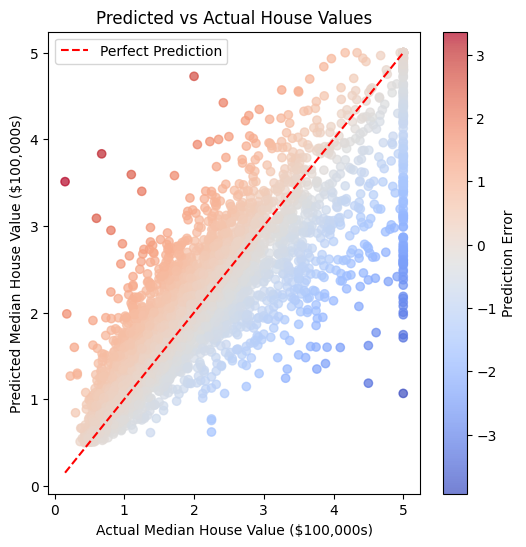

In [21]:
import matplotlib.pyplot as plt
import numpy as np

errors = y_pred - y_test

plt.figure(figsize=(6,6))
scatter = plt.scatter(y_test, y_pred, c=errors, cmap='coolwarm', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Median House Value ($100,000s)")
plt.ylabel("Predicted Median House Value ($100,000s)")
plt.title("Predicted vs Actual House Values")
plt.colorbar(scatter, label="Prediction Error")
plt.legend()
plt.show()


**10. Save trained pipeline**

In [12]:
# Save model as a pickle file
with open('california_knn_pipeline.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(" Model pipeline saved as 'california_knn_pipeline.pkl'")


 Model pipeline saved as 'california_knn_pipeline.pkl'


**11. Interactive Streamlit App for model deployment**

In [19]:
!pip install pyngrok --quiet
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "35QjLYdOml23DoB9cld7uxlZB1C_6fwsVTonfBexZHiPEMG3q"

# Register authtoken
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
print("ngrok authenticated successfully!")



ngrok authenticated successfully!


**12. Streamlit App**

In [18]:
%%writefile streamlit_app.py
import pickle
import pandas as pd
import streamlit as st
from io import BytesIO

# Load the saved model pipeline
with open("california_knn_pipeline.pkl", "rb") as f:
    model = pickle.load(f)

st.set_page_config(page_title="California Housing KNN Predictor", layout="wide")

st.title("California Housing Price Prediction (KNN Model)")
st.markdown("""
This interactive app predicts **median house values** (in $100,000s)
using the **California Housing Dataset** KNN regression model.
""")

# Tabs for single vs batch prediction
tab1, tab2 = st.tabs(["Single Prediction", "Batch Prediction (CSV Upload)"])

# Tab 1: Single Input
with tab1:
    st.sidebar.header("Enter Feature Values")

    MedInc = st.sidebar.number_input("Median Income (10k$)", 1.0, 15.0, 8.0)
    HouseAge = st.sidebar.number_input("House Age (years)", 1.0, 52.0, 20.0)
    AveRooms = st.sidebar.number_input("Average Rooms", 1.0, 15.0, 6.0)
    AveBedrms = st.sidebar.number_input("Average Bedrooms", 0.5, 5.0, 1.0)
    Population = st.sidebar.number_input("Population", 3.0, 10000.0, 500.0)
    AveOccup = st.sidebar.number_input("Average Occupancy", 1.0, 10.0, 3.0)
    Latitude = st.sidebar.number_input("Latitude", 32.0, 42.0, 37.0)
    Longitude = st.sidebar.number_input("Longitude", -125.0, -114.0, -120.0)

    if st.button("Predict House Value"):
        input_data = pd.DataFrame([{
            "MedInc": MedInc,
            "HouseAge": HouseAge,
            "AveRooms": AveRooms,
            "AveBedrms": AveBedrms,
            "Population": Population,
            "AveOccup": AveOccup,
            "Latitude": Latitude,
            "Longitude": Longitude
        }])

        prediction = model.predict(input_data)[0]
        st.success(f"**Predicted Median House Value:** ${prediction * 100000:,.2f}")

# Tab 2: Batch Prediction
with tab2:
    st.markdown("""
    Upload a CSV file containing the following columns:
    **MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude**
    """)

    uploaded_file = st.file_uploader("Upload your CSV file", type=["csv"])

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        st.write("### Uploaded Data Preview:")
        st.dataframe(df.head())

        # Validate columns
        required_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                         "Population", "AveOccup", "Latitude", "Longitude"]

        if all(col in df.columns for col in required_cols):
            if st.button("Run Batch Prediction"):
                preds = model.predict(df)
                df["Predicted_Median_Value($100,000s)"] = preds
                df["Predicted_Value($)"] = preds * 100000
                st.success("Batch predictions completed!")
                st.dataframe(df.head())

                # --- Download results as CSV ---
                csv_buffer = BytesIO()
                df.to_csv(csv_buffer, index=False)
                csv_buffer.seek(0)
                st.download_button(
                    label="Download Predictions CSV",
                    data=csv_buffer,
                    file_name="batch_predictions.csv",
                    mime="text/csv"
                )
        else:
            st.error(f"Missing required columns. Please include all of: {required_cols}")



Overwriting streamlit_app.py


**13. Run Streamlit app via ngrok**

In [20]:
from pyngrok import ngrok
import threading
import time
import subprocess

# Kill any existing tunnels
ngrok.kill()

# Run Streamlit app in background
def run_streamlit():
    subprocess.call(["streamlit", "run", "streamlit_app.py", "--server.port", "8501"])

thread = threading.Thread(target=run_streamlit)
thread.start()

# Wait for Streamlit to initialize
time.sleep(5)

# Expose public URL
public_url = ngrok.connect(8501).public_url
print("Streamlit App is live at:", public_url)


Streamlit App is live at: https://minna-premandibular-incalculably.ngrok-free.dev
